# Drafting Plots for Final Report

In [209]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt


# Corpus Preparation and Analysis

In [210]:
# Distribution of Articles by Year

con = duckdb.connect("../guardian_articles.duckdb", read_only=True)
df = con.execute(
    """
    SELECT 
        id, webTitle, webPublicationDate, clean_body
    FROM cleaned_articles
    """
).df()
con.close()

In [211]:
# average length of articles
df["word_count"] = df["clean_body"].str.split().str.len()

avg_len = df["word_count"].mean()
median_len = df["word_count"].median()

print("Average words:", avg_len)
print("Median words:", median_len)
df["word_count"].describe()

Average words: 1660.292295214923
Median words: 909.0


count    24660.000000
mean      1660.292295
std       2649.881760
min          0.000000
25%        648.000000
50%        909.000000
75%       1321.000000
max      40783.000000
Name: word_count, dtype: float64

In [212]:
summary = pd.DataFrame(
    {
        "Statistic": [
            "Count",
            "Mean",
            "Median",
            "Std. Dev.",
            "Min",
            "25th Percentile",
            "75th Percentile",
            "Max",
        ],
        "Value": [
            df["word_count"].count(),
            df["word_count"].mean(),
            df["word_count"].median(),
            df["word_count"].std(),
            df["word_count"].min(),
            df["word_count"].quantile(0.25),
            df["word_count"].quantile(0.75),
            df["word_count"].max(),
        ],
    }
)

# nice formatting
summary["Value"] = summary["Value"].round(2)
summary["Value"] = summary["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
)

# convert to markdown
md_table = summary.to_markdown(index=False)

print(md_table)

| Statistic       | Value     |
|:----------------|:----------|
| Count           | 24,660.00 |
| Mean            | 1,660.29  |
| Median          | 909.00    |
| Std. Dev.       | 2,649.88  |
| Min             | 0.00      |
| 25th Percentile | 648.00    |
| 75th Percentile | 1,321.00  |
| Max             | 40,783.00 |


In [213]:
max_idx = df["word_count"].idxmax()
max_article = df.loc[max_idx]

print(max_article[["webTitle", "word_count"]])

webTitle      Rachel Reeves becomes UK’s first female chance...
word_count                                                40783
Name: 18870, dtype: object


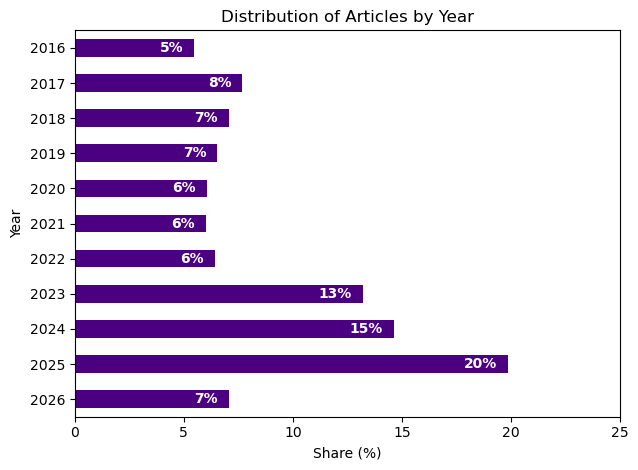

In [214]:
# plotting number of articles by year
df["webPublicationDate"] = pd.to_datetime(df["webPublicationDate"])
df["year"] = df["webPublicationDate"].dt.year
summary_year = df["year"].value_counts().sort_index(ascending=False).to_frame("Count")
summary_year["Share (%)"] = (
    summary_year["Count"] / summary_year["Count"].sum() * 100
).round(2)

plt.figure()
ax = summary_year["Share (%)"].plot(
    kind="barh",
    color="#4B0082",
)
plt.xlabel("Share (%)")
plt.ylabel("Year")
plt.title("Distribution of Articles by Year")

# data labels
for i, v in enumerate(summary_year["Share (%)"]):
    ax.text(
        v - 0.5,  # just inside the end of the bar
        i,
        f"{v:.0f}%",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
ax.set_xlim(0, 25)
plt.show()

# Topic Modeling

In [215]:
# total number of topics from first model
# article_topics
con = duckdb.connect("../guardian_articles.duckdb", read_only=True)
df_topics = con.execute(
    """
    SELECT 
        a.id, a.webTitle, a.webPublicationDate, a.text, a.clean_body, a.topic_id, a.topic_prob, a.topic_label,
        l.topic_label_clean
    FROM article_topics a JOIN article_topics_labelled l ON a.id = l.id
    """
).df()
# df_topics
con.close()
print(df_topics.columns.tolist())


['id', 'webTitle', 'webPublicationDate', 'text', 'clean_body', 'topic_id', 'topic_prob', 'topic_label', 'topic_label_clean']


In [216]:
# bring in the labelled topics table
con = duckdb.connect("../guardian_articles.duckdb", read_only=True)
df_topics_labelled = con.execute(
    """
    SELECT *
    FROM article_topics_labelled
    """
).df()
con.close()

In [217]:
print(df_topics_labelled.columns.tolist())


['id', 'webTitle', 'webPublicationDate', 'topic_id', 'topic_prob', 'topic_label', 'source', 'clean_body', 'text', 'topic_label_clean']


In [218]:
df_topics_labelled["source"].unique()

array(['main_model', 'outlier_model', 'uncategorised'], dtype=object)

In [219]:
df_topics_labelled["source"].value_counts()

source
main_model       15955
uncategorised     7883
outlier_model      822
Name: count, dtype: int64

In [220]:
first_model = df_topics_labelled[df_topics_labelled["source"] == "main_model"]

In [221]:
first_model["source"]

0        main_model
1        main_model
3        main_model
5        main_model
6        main_model
            ...    
24653    main_model
24655    main_model
24656    main_model
24657    main_model
24659    main_model
Name: source, Length: 15955, dtype: object

In [222]:
# total number of topics from first model
df_topics["topic_label"].nunique()

56

In [223]:
# top 10 topics by count from the first model
topic_table = first_model["topic_label_clean"].value_counts().reset_index()
topic_table.columns = ["Topic", "Count"]
# hard coding the total number of articles here
topic_table["Share (%)"] = (topic_table["Count"] / 24660 * 100).round(2)
topic_table["Count"] = topic_table["Count"].apply(lambda x: f"{x:,}")
topic_table["Share (%)"] = topic_table["Share (%)"].astype(str) + "%"
topic_table = topic_table.head(10)
styled = topic_table.style.set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = topic_table.style.hide(axis="index")
styled  # print the table

Topic,Count,Share (%)
Government and Politics,"13,766",55.82%
Football & Soccer,926,3.76%
Olympics,136,0.55%
Sleep,110,0.45%
Christmas Trees,80,0.32%
Classical Music,47,0.19%
Formula 1,36,0.15%
Basketball,34,0.14%
Cosmetic Products,34,0.14%
Space Exploration,32,0.13%


In [224]:
# total number of topics from second model
# article_topics_outliers
con = duckdb.connect("../guardian_articles.duckdb", read_only=True)
df_topics_outliers = con.execute(
    """
    SELECT * 
    FROM article_topics_outliers
    """
).df()
# df_topics_outliers
con.close()
# df_topics_outliers.columns.tolist()
df_topics_outliers["outlier_topic_label"].nunique()

63

In [225]:
second_model = df_topics_labelled[df_topics_labelled["source"] == "outlier_model"]

In [226]:
first_model["topic_label_clean"].nunique()

55

In [227]:
second_model["topic_label_clean"].nunique()

61

In [228]:
second_model["topic_label"].nunique()

61

In [229]:
df_grouped = (
    df_topics_labelled.groupby("source")["topic_label_clean"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)

df_grouped

,source,topic_label_clean
0,main_model,"[Abortion Policy, Air Pollution, Astronomy, Ba..."
1,outlier_model,"[AI and Data Centers, Amazon and Indigenous Co..."
2,uncategorised,[Uncategorized]


In [230]:
topic_lookup = (
    second_model[["topic_id", "topic_label_clean"]]
    .drop_duplicates()
    .sort_values("topic_id")
    .reset_index(drop=True)
)

topic_lookup

,topic_id,topic_label_clean
0,56,Google Products
1,57,Dinosaurs
2,58,Night and Nocturnal Creatures
3,59,Glaciers
4,60,The NHS and British Healthcare
...,...,...
56,112,Miscellaneous Sports
57,113,Arguments and Relationships
58,114,South African Relations with the United States
59,115,Medicare


In [231]:
topic_counts = (
    df_topics_labelled.groupby("source")["topic_id"]
    .nunique()
    .reset_index(name="n_topic_ids")
)

topic_counts

,source,n_topic_ids
0,main_model,55
1,outlier_model,61
2,uncategorised,1


In [232]:
# topic table after merging and hand-labelling
df_topics_labelled = df_topics_labelled.copy()

df_topics_labelled["source"] = df_topics_labelled["source"].replace(
    {
        "main_model": "First Model",
        "outlier_model": "Subcorpus Model",
        "uncategorised": "Uncategorized",
    }
)

# ── aggregate counts ─────────────────────────────────────────────────────────
topic_table = (
    df_topics_labelled.groupby(["source", "topic_label_clean"])
    .size()
    .reset_index(name="Count")
)

# ── GLOBAL share (NOT per source) ────────────────────────────────────────────
total = topic_table["Count"].sum()

topic_table["Share (%)"] = (topic_table["Count"] / total * 100).round(2)

# ── sort globally by count ───────────────────────────────────────────────────
topic_table = topic_table.sort_values("Count", ascending=False)
topic_table = topic_table.head(20)
topic_table = topic_table.rename(
    columns={
        "source": "Source",
        "topic_label_clean": "Topic",
        "Count": "Count",
        "Share (%)": "Share (%)",
    }
)
# ── formatting for display ────────────────────────────────────────────────────
topic_table["Count"] = topic_table["Count"].apply(lambda x: f"{x:,}")
topic_table["Share (%)"] = topic_table["Share (%)"].astype(str) + "%"

print(topic_table.to_string(index=False))

         Source                               Topic  Count Share (%)
    First Model             Government and Politics 13,766    55.82%
  Uncategorized                       Uncategorized  7,883    31.97%
    First Model                   Football & Soccer    926     3.76%
    First Model                            Olympics    136     0.55%
    First Model                               Sleep    110     0.45%
Subcorpus Model                     Google Products    106     0.43%
    First Model                     Christmas Trees     80     0.32%
    First Model                     Classical Music     47     0.19%
    First Model                           Formula 1     36     0.15%
    First Model                          Basketball     34     0.14%
    First Model                   Cosmetic Products     34     0.14%
Subcorpus Model                           Dinosaurs     33     0.13%
Subcorpus Model      The NHS and British Healthcare     33     0.13%
    First Model                   

In [233]:
styled = topic_table.style.set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = topic_table.style.hide(axis="index")
styled  # print the table

Source,Topic,Count,Share (%)
First Model,Government and Politics,"13,766",55.82%
Uncategorized,Uncategorized,"7,883",31.97%
First Model,Football & Soccer,926,3.76%
First Model,Olympics,136,0.55%
First Model,Sleep,110,0.45%
Subcorpus Model,Google Products,106,0.43%
First Model,Christmas Trees,80,0.32%
First Model,Classical Music,47,0.19%
First Model,Formula 1,36,0.15%
First Model,Basketball,34,0.14%


In [234]:
# median number of articles per topic

# min, max (run summary)
# ── 1. count articles per topic ──────────────────────────────────────────────
topic_counts = df_topics_labelled["topic_label_clean"].value_counts()

# ── 2. summary stats ─────────────────────────────────────────────────────────
summary = topic_counts.describe()

# ── 3. add median explicitly (describe doesn't emphasize it)
# summary["median"] = topic_counts.median()

summary

count      117.000000
mean       210.769231
std       1460.351247
min          5.000000
25%         10.000000
50%         14.000000
75%         20.000000
max      13766.000000
Name: count, dtype: float64

In [235]:
summary_table = pd.DataFrame(
    {
        "Statistic": ["Mean", "Median", "Min", "Max"],
        "Value": [
            topic_counts.mean(),
            topic_counts.median(),
            topic_counts.min(),
            topic_counts.max(),
        ],
    }
)

summary_table["Value"] = summary_table["Value"].round(2)

summary_table

,Statistic,Value
0,Mean,210.77
1,Median,14.00
2,Min,5.00
3,Max,13766.00


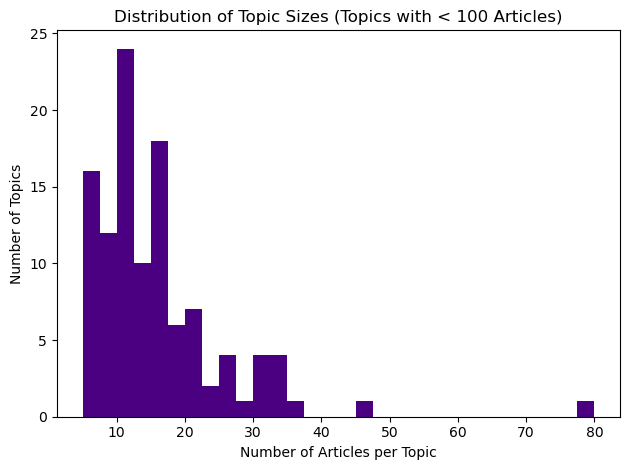

In [236]:
# histogram of topics and article counts
import matplotlib.pyplot as plt

# topic_counts = articles per topic
topic_counts = df_topics_labelled["topic_label_clean"].value_counts()

plt.figure()

plt.hist(topic_counts[topic_counts < 100], bins=30, color="#4B0082")

plt.xlabel("Number of Articles per Topic")
plt.ylabel("Number of Topics")
plt.title("Distribution of Topic Sizes (Topics with < 100 Articles)")

plt.tight_layout()
plt.show()

In [237]:
# count of topics with fewer than 25 articles or fewer than 10
n_lt_25 = (topic_counts < 25).sum()
n_lt_10 = (topic_counts < 10).sum()
summary = pd.DataFrame(
    {
        "Threshold": ["< 25 articles", "< 10 articles"],
        "Number of Topics": [n_lt_25, n_lt_10],
    }
)

summary["Number of Topics"] = summary["Number of Topics"].apply(lambda x: f"{x:,}")

summary

,Threshold,Number of Topics
0,< 25 articles,95
1,< 10 articles,28


Topics that appear to be explicitly about artificial intelligence:
- Technology, AI, and Alcohol
- AI and Data Centers
- Google Products

Close reading of one of these (Technology, AI, and Alcohol)

In [238]:
# Maori Tattoo Example

# extract the webTitle and text of articles related to the Maori Tattoo Example

maori_tattoo_articles = df_topics_labelled[
    df_topics_labelled["topic_label_clean"] == "Maori Facial Tattoos"
]
# len(maori_tattoo_articles)
# only one of these articles actually seems to mention artificial intelligence


In [239]:
# merge in the search terms to see what the issue is
con = duckdb.connect("../guardian_articles.duckdb", read_only=True)
df_maori = con.execute(
    """
    SELECT 
        l.id, l.webTitle, l.webPublicationDate, l.text, l.clean_body, l.topic_id, l.topic_prob, l.topic_label, l.topic_label_clean,
        c.search_terms
    FROM article_topics_labelled l JOIN cleaned_articles c ON l.id = c.id
    WHERE l.topic_label_clean = 'Maori Culture and Tattoos'
    """
).df()
# df_topics
con.close()

In [244]:
table = df_maori[["webTitle", "search_terms"]].copy()

table = table.rename(
    columns={"webTitle": "Article Title", "search_terms": "Search Terms"}
)
styled = table.style.hide(axis="index").set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
    ]
)

styled

Article Title,Search Terms
Getting a terrible tattoo when you’re young feels like a life lesson – yet so many people still crave more,artificial intelligence
Snapchat removes Māori face tattoo filters after outcry in New Zealand,"AI, generative AI"
"Nōku e whakaora mai ana i tōku reo Māori, i kaha te pā mai o te wawaro e tō ana i a au kia haere ki te moana | Shilo Kino","AI, generative AI"
Jacinda Ardern's speech at Christchurch memorial – full transcript,"AI, generative AI"
Māori moko facial tattoos revived by a new generation with designs on the future,generative AI
"Moana Jackson was the most articulate, original and forceful intellectual of his generation | Morgan Godfrey",generative AI


Although these articles came in through the data pipeline under the terms "AI", "generative AI", and "artificial intelligence", only one article, "Snapchat removes Māori face tattoo filters after outcry in New Zealand", explicitly mentions artificial intelligence. Upon close reading, this article discusses debates over the addictive nature of tattoos and recent advances in tatto-related technology. The explicit mention of artificial intelligence occurs in the sentence "Today, there are robot tattoo artists that use artificial intelligence, tattoos done with disappearing ink that manufacturers claim last a year or two, software and apps for better design, temporary face tattoos that supposedly decode brainwaves to measure mental strain, and an increasing demand for laser tattoo removal."

Some of these articles also differed from their peers in terms of focus. Three articles "Getting a terrible tattoo when you’re young feels like a life lesson – yet so many people still crave more", "Snapchat removes Māori face tattoo filters after outcry in New Zealand", "Māori moko facial tattoos revived by a new generation with designs on the future", mentioned tattoos, while the latter two specifically mentioned traditional Māori facial tattoos. One article, "Jacinda Ardern's speech at Christchurch memorial – full transcript" was the transcript of a speech by former Prime Minister of New Zealand in response to the 2019 Christchurch mosque shootings. Another article included in this topic "Nōku e whakaora mai ana i tōku reo Māori, i kaha te pā mai o te wawaro e tō ana i a au kia haere ki te moana | Shilo Kino" is written in te reo Māori by the Māori journalist Shilo Kino. This introduces an interesting example of the BERT-based topic model, which was trained on English corpora, clustering an article in a non-English language. 

The article "Moana Jackson was the most articulate, original and forceful intellectual of his generation | Morgan Godfrey" is an obituary for Moana Jackson, a Māori lawyer and activist, written by the columnist Morgan Godfery. There are two notable errors in the inclusion of this article in the data ingestion pipeline. First, although the article was retrieved from the API search through the search term "generative AI", there is no mention in the obituary of artificial intelligence or generative AI. Instead, it appears that the word "generation" was deemed close enough to the "generative AI" search term to identify this article for retrieval, suggesting the use of a fuzzy matching algorithm in the API search. Ultimately, this sort of keyword search is unhelpful in serving my original intent of retrieving articles from the API related to the concept of artificial intelligence and generative AI. Second, when accessing this website through the online website for *The Guardian*, I noted that the author's true name is "Morgan Godfery", while the `webTitle` parameter returned by the API search instead includes the name "Morgan Godfrey", indicating some errors in the database queried by the API search. 

In [242]:
# put full topic table in the appendix
df_topics_labelled = df_topics_labelled.copy()

df_topics_labelled["source"] = df_topics_labelled["source"].replace(
    {
        "main_model": "First Model",
        "outlier_model": "Subcorpus Model",
        "uncategorised": "Uncategorized",
    }
)

# ── aggregate counts ─────────────────────────────────────────────────────────
topic_table = (
    df_topics_labelled.groupby(["source", "topic_label_clean"])
    .size()
    .reset_index(name="Count")
)

# ── GLOBAL share (NOT per source) ────────────────────────────────────────────
total = topic_table["Count"].sum()

topic_table["Share (%)"] = (topic_table["Count"] / total * 100).round(2)

# ── sort globally by count ───────────────────────────────────────────────────
topic_table = topic_table.sort_values("Count", ascending=False)
# topic_table = topic_table.head(20)
topic_table = topic_table.rename(
    columns={
        "source": "Source",
        "topic_label_clean": "Topic",
        "Count": "Count",
        "Share (%)": "Share (%)",
    }
)
# ── formatting for display ────────────────────────────────────────────────────
topic_table["Count"] = topic_table["Count"].apply(lambda x: f"{x:,}")
topic_table["Share (%)"] = topic_table["Share (%)"].astype(str) + "%"

# print(topic_table.to_string(index=False))

styled = topic_table.style.set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = topic_table.style.hide(axis="index")
styled  # print the table


Source,Topic,Count,Share (%)
First Model,Government and Politics,"13,766",55.82%
Uncategorized,Uncategorized,"7,883",31.97%
First Model,Football & Soccer,926,3.76%
First Model,Olympics,136,0.55%
First Model,Sleep,110,0.45%
Subcorpus Model,Google Products,106,0.43%
First Model,Christmas Trees,80,0.32%
First Model,Classical Music,47,0.19%
First Model,Formula 1,36,0.15%
First Model,Basketball,34,0.14%


# Named Entity Recognition